# 06 Improved Modeling

Fixes the issues found in the NHAMCS documentation and adds new approaches

**What wad changed from previous modeling notebooks:**
1. Sample weights (PATWT) - each record represents a different number of real visits
2. REGION + MSA added as features
3. All sentinel values (-9, -8, 998, 999) properly cleaned
4. TEMPF fixed from 10x format (986 → 98.6)
5. Train/test split fixed - actually uses 2015-2018 data for training
6. Log-transformed target to handle extreme skew
7. Classification models - predicts "will wait exceed 30/60 min?" instead of exact minutes
8. Engineered features - cyclical hour/month, weekend flag, peak hour flag

## Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
data_dir = Path('../data')
print('Imports loaded.')

Imports loaded.


## Load the updated dataset

In [2]:
eda_df = pd.read_csv(data_dir / 'eda_df.csv')
print(f'Loaded eda_df: {eda_df.shape}')

# Force numeric on key columns
numeric_force = [
    'WAITTIME', 'YEAR', 'ARRIVAL_HOUR', 'VMONTH', 'VDAYR',
    'AGE', 'SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'PAINSCALE',
    'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT',
    'PATWT', 'REGION', 'MSA', 'FASTTRAK', 'OBSCLIN',
    'BEDREG', 'IMBED', 'BEDCZAR',
]
for c in numeric_force:
    if c in eda_df.columns:
        eda_df[c] = pd.to_numeric(eda_df[c], errors='coerce')

# Check that REGION and PATWT exist
for c in ['REGION', 'MSA', 'PATWT']:
    if c in eda_df.columns:
        print(f'{c}: {eda_df[c].notna().sum()} non-null')
    else:
        print(f'WARNING: {c} NOT FOUND - re-run updated 01_data_prep.ipynb!')

Loaded eda_df: (121026, 38)
REGION: 121026 non-null
MSA: 121026 non-null
PATWT: 121026 non-null


## Thorough sentinel value cleaning

NHAMCS uses negative values (-9, -8, -7) and high values (998, 999) as codes for 
blank/unknown/not applicable. These need to be replaced with NaN, not treated as real numbers.

In [3]:
sentinel_map = {
    'PAINSCALE': {-9, -8, 99},
    'BPSYS':     {-9, -8, 998, 999},
    'BPDIAS':    {-9, -8, 998, 999},
    'TEMPF':     {-9, -8, 998, 999, 9980, 9990, 9989, 9999},
    'PULSE':     {-9, -8, 998, 999},
    'RESPR':     {-9, -8, 98, 99, 998, 999},
    'POPCT':     {-9, -8, 998, 999},
    'IMMEDR':    {-8, -9, 8, 9, 98, 99},
    'SEX':       {-9, 9, 99},
    'RACEUN':    {-9, 9, 99},
    'ETHUN':     {-9, 9, 99},
    'LOV':       {-9, -8},
    'BOARD':     {-9, -8},
    'BOARDHOS':  {-9, -8},
    'ADMIT':     {-9, -8},
    'FASTTRAK':  {-9, -8},
    'OBSCLIN':   {-9, -8},
    'BEDREG':    {-9, -8},
    'IMBED':     {-9, -8},
    'BEDCZAR':   {-9, -8},
}

for col, bad_vals in sentinel_map.items():
    if col in eda_df.columns:
        n_bad = eda_df[col].isin(bad_vals).sum()
        if n_bad > 0:
            print(f'  {col}: replacing {n_bad} sentinel values with NaN')
            eda_df.loc[eda_df[col].isin(bad_vals), col] = np.nan

# Fix TEMPF: values 850-1150 are stored as 10x (e.g., 986 = 98.6)
if 'TEMPF' in eda_df.columns:
    mask = eda_df['TEMPF'].between(850, 1150)
    eda_df.loc[mask, 'TEMPF'] = eda_df.loc[mask, 'TEMPF'] / 10.0
    print(f'  TEMPF: converted {mask.sum()} values from 10x format')

# Filter valid wait times
eda_df = eda_df[eda_df['WAITTIME'].between(0, 480)].copy()
print(f'\nAfter cleaning: {eda_df.shape}')

# Sanity check
for c in ['PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE']:
    if c in eda_df.columns:
        print(f'  {c}: mean={eda_df[c].mean():.1f}, min={eda_df[c].min():.1f}, max={eda_df[c].max():.1f}')

  PAINSCALE: replacing 41410 sentinel values with NaN
  BPSYS: replacing 11603 sentinel values with NaN
  BPDIAS: replacing 11794 sentinel values with NaN
  TEMPF: replacing 6673 sentinel values with NaN
  PULSE: replacing 6428 sentinel values with NaN
  RESPR: replacing 4370 sentinel values with NaN
  POPCT: replacing 6624 sentinel values with NaN
  IMMEDR: replacing 25965 sentinel values with NaN
  RACEUN: replacing 22430 sentinel values with NaN
  ETHUN: replacing 21654 sentinel values with NaN
  LOV: replacing 1695 sentinel values with NaN
  BOARD: replacing 7078 sentinel values with NaN
  BOARDHOS: replacing 9643 sentinel values with NaN
  ADMIT: replacing 1670 sentinel values with NaN
  FASTTRAK: replacing 7466 sentinel values with NaN
  OBSCLIN: replacing 7454 sentinel values with NaN
  BEDREG: replacing 5045 sentinel values with NaN
  IMBED: replacing 8617 sentinel values with NaN
  BEDCZAR: replacing 8820 sentinel values with NaN
  TEMPF: converted 114352 values from 10x forma

## Build features and engineer new ones

In [4]:
df = eda_df.copy()

# Define feature groups
arrival_features = [
    'ARRIVAL_HOUR', 'VMONTH', 'VDAYR', 'AGE', 'SEX',
    'RACEUN', 'ETHUN', 'IMMEDR', 'PAINSCALE',
    'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT',
]
region_features = ['REGION', 'MSA']
operational_features = ['FASTTRAK', 'OBSCLIN', 'BEDREG', 'IMBED', 'BEDCZAR']

base_features = [c for c in arrival_features + region_features + operational_features if c in df.columns]

# Categorical vs numeric
cat_features = [c for c in ['SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'VDAYR', 'VMONTH',
                             'REGION', 'MSA', 'FASTTRAK', 'OBSCLIN',
                             'BEDREG', 'IMBED', 'BEDCZAR'] if c in base_features]
num_features = [c for c in base_features if c not in cat_features]

# Engineer new features
if 'ARRIVAL_HOUR' in df.columns:
    h = df['ARRIVAL_HOUR']
    df['HOUR_SIN'] = np.sin(2 * np.pi * h / 24.0)
    df['HOUR_COS'] = np.cos(2 * np.pi * h / 24.0)
    df['IS_PEAK'] = h.between(13, 20).astype(float)
    num_features += ['HOUR_SIN', 'HOUR_COS', 'IS_PEAK']

if 'VMONTH' in df.columns:
    m = df['VMONTH']
    df['MONTH_SIN'] = np.sin(2 * np.pi * m / 12.0)
    df['MONTH_COS'] = np.cos(2 * np.pi * m / 12.0)
    num_features += ['MONTH_SIN', 'MONTH_COS']

if 'VDAYR' in df.columns:
    df['IS_WEEKEND'] = df['VDAYR'].isin([1, 7]).astype(float)
    num_features.append('IS_WEEKEND')

# Log-transformed target
df['LOG_WAITTIME'] = np.log1p(df['WAITTIME'])

all_features = num_features + cat_features
print(f'Total features: {len(all_features)}')
print(f'  Numeric ({len(num_features)}): {num_features}')
print(f'  Categorical ({len(cat_features)}): {cat_features}')

Total features: 28
  Numeric (15): ['ARRIVAL_HOUR', 'AGE', 'PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT', 'HOUR_SIN', 'HOUR_COS', 'IS_PEAK', 'MONTH_SIN', 'MONTH_COS', 'IS_WEEKEND']
  Categorical (13): ['SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'VDAYR', 'VMONTH', 'REGION', 'MSA', 'FASTTRAK', 'OBSCLIN', 'BEDREG', 'IMBED', 'BEDCZAR']


## Train/test split by year (FIXED)

The original notebook only had 2022 data in model_A, so train was empty.
Now we use the full multi-year data.

In [5]:
print('Year distribution:')
print(df['YEAR'].value_counts().sort_index())

train_years = [2015, 2016, 2017, 2018]
valid_years = [2019, 2020, 2021]
holdout_years = [2022]

train_df = df[df['YEAR'].isin(train_years)].copy()
valid_df = df[df['YEAR'].isin(valid_years)].copy()
holdout_df = df[df['YEAR'].isin(holdout_years)].copy()

print(f'\nTrain ({train_years}): {len(train_df)} rows')
print(f'Valid ({valid_years}): {len(valid_df)} rows')
print(f'Holdout ({holdout_years}): {len(holdout_df)} rows')

# Prepare X, y
X_train = train_df[all_features].copy()
X_valid = valid_df[all_features].copy()
X_holdout = holdout_df[all_features].copy()

y_train = train_df['WAITTIME'].values
y_valid = valid_df['WAITTIME'].values
y_holdout = holdout_df['WAITTIME'].values

y_train_log = train_df['LOG_WAITTIME'].values
y_holdout_log = holdout_df['LOG_WAITTIME'].values

# Extract and normalize sample weights
if 'PATWT' in train_df.columns:
    w_train = train_df['PATWT'].fillna(train_df['PATWT'].median()).values
    w_train = w_train / w_train.mean()  # normalize so mean = 1
    HAS_WEIGHTS = True
    print(f'\nSample weights loaded from PATWT (normalized)')
else:
    w_train = np.ones(len(train_df))
    HAS_WEIGHTS = False
    print(f'\nPATWT not found. Training without weights.')

# Fill NaN in features
for c in num_features:
    for frame in [X_train, X_valid, X_holdout]:
        frame[c] = pd.to_numeric(frame[c], errors='coerce')

for c in cat_features:
    for frame in [X_train, X_valid, X_holdout]:
        frame[c] = frame[c].fillna(-99).astype(float)

train_medians = X_train[num_features].median()
for frame in [X_train, X_valid, X_holdout]:
    for c in num_features:
        frame[c] = frame[c].fillna(train_medians[c])

Year distribution:
YEAR
2015.0    17035
2016.0    16243
2017.0    14327
2018.0    17161
2019.0    16285
2020.0    12929
2021.0    13830
2022.0    13216
Name: count, dtype: int64

Train ([2015, 2016, 2017, 2018]): 64766 rows
Valid ([2019, 2020, 2021]): 43044 rows
Holdout ([2022]): 13216 rows

Sample weights loaded from PATWT (normalized)


## Baseline: hourly median from training set

In [6]:
hour_medians = train_df.groupby('ARRIVAL_HOUR')['WAITTIME'].median()
global_median = train_df['WAITTIME'].median()

def baseline_predict(frame):
    return frame['ARRIVAL_HOUR'].map(hour_medians).fillna(global_median).values

base_train = baseline_predict(X_train)
base_valid = baseline_predict(X_valid)
base_holdout = baseline_predict(X_holdout)

base_mae = mean_absolute_error(y_holdout, base_holdout)
base_rmse = np.sqrt(mean_squared_error(y_holdout, base_holdout))
base_r2 = r2_score(y_holdout, base_holdout)
print(f'Baseline (hourly median): MAE={base_mae:.2f}, RMSE={base_rmse:.2f}, R2={base_r2:.4f}')

Baseline (hourly median): MAE=28.34, RMSE=56.00, R2=-0.1005


## Model A: Gradient Boosting with sample weights

In [7]:
print('Training HGB with sample weights...')

hgb_model = HistGradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=0.1,
    random_state=42,
)
hgb_model.fit(X_train, y_train, sample_weight=w_train)

pred_holdout_hgb = np.clip(hgb_model.predict(X_holdout), 0, 480)

mae_h = mean_absolute_error(y_holdout, pred_holdout_hgb)
rmse_h = np.sqrt(mean_squared_error(y_holdout, pred_holdout_hgb))
r2_h = r2_score(y_holdout, pred_holdout_hgb)
print(f'Holdout: MAE={mae_h:.2f}, RMSE={rmse_h:.2f}, R2={r2_h:.4f}')

Training HGB with sample weights...
Holdout: MAE=28.54, RMSE=55.63, R2=-0.0862


## Model B: Log-transformed target

In [8]:
print('Training HGB on log(WAITTIME+1)...')

hgb_log = HistGradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=0.1,
    random_state=42,
)
hgb_log.fit(X_train, y_train_log, sample_weight=w_train)

pred_holdout_log = np.expm1(np.clip(hgb_log.predict(X_holdout), 0, None))
pred_holdout_log = np.clip(pred_holdout_log, 0, 480)

mae_log = mean_absolute_error(y_holdout, pred_holdout_log)
rmse_log = np.sqrt(mean_squared_error(y_holdout, pred_holdout_log))
r2_log = r2_score(y_holdout, pred_holdout_log)
print(f'Holdout: MAE={mae_log:.2f}, RMSE={rmse_log:.2f}, R2={r2_log:.4f}')

Training HGB on log(WAITTIME+1)...
Holdout: MAE=28.53, RMSE=55.88, R2=-0.0956


## Model C: Residual (hourly median + HGB correction)

In [9]:
print('Training residual HGB...')

resid_model = HistGradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.04,
    max_iter=350,
    max_depth=7,
    min_samples_leaf=40,
    l2_regularization=0.15,
    random_state=42,
)
resid_model.fit(X_train, y_train - base_train, sample_weight=w_train)

pred_holdout_resid = np.clip(base_holdout + resid_model.predict(X_holdout), 0, 480)

mae_resid = mean_absolute_error(y_holdout, pred_holdout_resid)
rmse_resid = np.sqrt(mean_squared_error(y_holdout, pred_holdout_resid))
r2_resid = r2_score(y_holdout, pred_holdout_resid)
print(f'Holdout: MAE={mae_resid:.2f}, RMSE={rmse_resid:.2f}, R2={r2_resid:.4f}')

Training residual HGB...
Holdout: MAE=28.58, RMSE=55.58, R2=-0.0841


## Model D: Classification (will wait > 30 minutes?)

Instead of predicting exact minutes, we predict a yes/no question.
This is more actionable and usually more accurate.

In [10]:
print('Training classifier: wait > 30 minutes?')

y_train_cls = (y_train > 30).astype(int)
y_holdout_cls = (y_holdout > 30).astype(int)

cls_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=0.1,
    random_state=42,
)
cls_model.fit(X_train, y_train_cls, sample_weight=w_train)

pred_cls = cls_model.predict(X_holdout)

acc = accuracy_score(y_holdout_cls, pred_cls)
f1 = f1_score(y_holdout_cls, pred_cls)

print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print()
print(classification_report(y_holdout_cls, pred_cls, target_names=['<= 30 min', '> 30 min']))

Training classifier: wait > 30 minutes?
Accuracy: 0.7023
F1 Score: 0.1316

              precision    recall  f1-score   support

   <= 30 min       0.71      0.97      0.82      9251
    > 30 min       0.53      0.08      0.13      3965

    accuracy                           0.70     13216
   macro avg       0.62      0.52      0.48     13216
weighted avg       0.66      0.70      0.61     13216



## Model E: Classification (will wait > 60 minutes?)

In [11]:
print('Training classifier: wait > 60 minutes?')

y_train_cls60 = (y_train > 60).astype(int)
y_holdout_cls60 = (y_holdout > 60).astype(int)

cls60_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=30,
    random_state=42,
)
cls60_model.fit(X_train, y_train_cls60, sample_weight=w_train)

pred_cls60 = cls60_model.predict(X_holdout)
acc60 = accuracy_score(y_holdout_cls60, pred_cls60)
f160 = f1_score(y_holdout_cls60, pred_cls60)

print(f'Accuracy: {acc60:.4f}')
print(f'F1 Score: {f160:.4f}')
print()
print(classification_report(y_holdout_cls60, pred_cls60, target_names=['<= 60 min', '> 60 min']))

Training classifier: wait > 60 minutes?
Accuracy: 0.8410
F1 Score: 0.0141

              precision    recall  f1-score   support

   <= 60 min       0.84      1.00      0.91     11118
    > 60 min       0.44      0.01      0.01      2098

    accuracy                           0.84     13216
   macro avg       0.64      0.50      0.46     13216
weighted avg       0.78      0.84      0.77     13216



## Compare all regression models

In [12]:
results = pd.DataFrame([
    {'Model': 'Baseline (hourly median)', 'MAE': base_mae, 'RMSE': base_rmse, 'R2': base_r2},
    {'Model': 'HGB weighted', 'MAE': mae_h, 'RMSE': rmse_h, 'R2': r2_h},
    {'Model': 'HGB log-target', 'MAE': mae_log, 'RMSE': rmse_log, 'R2': r2_log},
    {'Model': 'Residual HGB weighted', 'MAE': mae_resid, 'RMSE': rmse_resid, 'R2': r2_resid},
]).sort_values('MAE')

print('REGRESSION MODEL COMPARISON (holdout set)')
print('=' * 65)
display(results.reset_index(drop=True))

print(f'\nCLASSIFICATION RESULTS')
print(f'  Wait > 30 min?  Accuracy={acc:.3f}, F1={f1:.3f}')
print(f'  Wait > 60 min?  Accuracy={acc60:.3f}, F1={f160:.3f}')

REGRESSION MODEL COMPARISON (holdout set)


,Model,MAE,RMSE,R2
0,Baseline (hourly median),28.344885,55.999156,-0.100491
1,HGB log-target,28.525992,55.875282,-0.095627
2,HGB weighted,28.540523,55.633096,-0.086150
3,Residual HGB weighted,28.583929,55.580332,-0.084091



CLASSIFICATION RESULTS
  Wait > 30 min?  Accuracy=0.702, F1=0.132
  Wait > 60 min?  Accuracy=0.841, F1=0.014


## Visualize model comparison

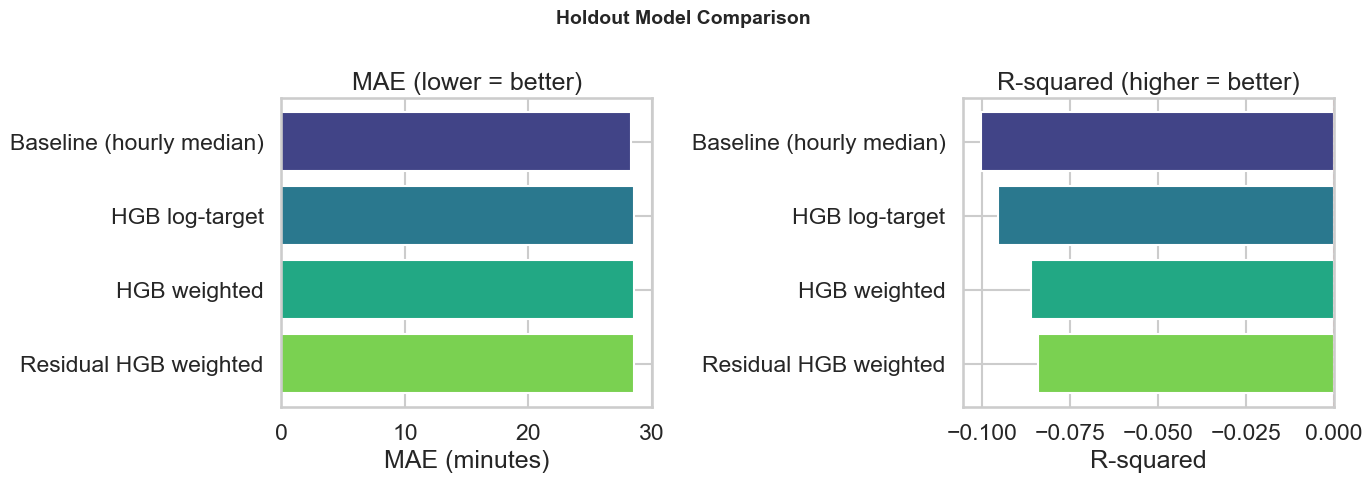

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results['Model'].tolist()
colors_list = sns.color_palette('viridis', len(model_names))

axes[0].barh(model_names, results['MAE'], color=colors_list)
axes[0].set_xlabel('MAE (minutes)')
axes[0].set_title('MAE (lower = better)')
axes[0].invert_yaxis()

axes[1].barh(model_names, results['R2'], color=colors_list)
axes[1].set_xlabel('R-squared')
axes[1].set_title('R-squared (higher = better)')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.suptitle('Holdout Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature importance

In [14]:
if hasattr(hgb_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': hgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print('Top 20 features:')
    display(imp_df.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 20 Feature Importances (Weighted HGB)')
    plt.tight_layout()
    plt.show()

## Regional analysis

In [15]:
if 'REGION' in holdout_df.columns:
    region_map = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}

    analysis = holdout_df[['WAITTIME', 'REGION']].copy()
    analysis['PREDICTED'] = pred_holdout_hgb
    analysis['REGION_NAME'] = analysis['REGION'].map(region_map)
    analysis['ABS_ERROR'] = np.abs(analysis['WAITTIME'] - analysis['PREDICTED'])

    region_perf = analysis.groupby('REGION_NAME').agg(
        count=('WAITTIME', 'count'),
        actual_mean=('WAITTIME', 'mean'),
        predicted_mean=('PREDICTED', 'mean'),
        mae=('ABS_ERROR', 'mean')
    ).round(2)

    print('Model performance by region:')
    display(region_perf)
else:
    print('REGION not available. Re-run updated 01_data_prep.ipynb.')

Model performance by region:


,count,actual_mean,predicted_mean,mae
REGION_NAME,,,,
Midwest,3849,29.39,16.59,26.97
Northeast,2611,40.62,21.64,34.76
South,3702,39.56,16.82,30.84
West,3054,27.02,15.82,22.41


## Save results

In [16]:
results.to_csv(data_dir / 'model_eval_improved_v2.csv', index=False)

holdout_out = holdout_df[['WAITTIME', 'YEAR', 'ARRIVAL_HOUR']].copy()
holdout_out['pred_baseline'] = base_holdout
holdout_out['pred_hgb_weighted'] = pred_holdout_hgb
holdout_out['pred_log'] = pred_holdout_log
holdout_out['pred_residual'] = pred_holdout_resid
holdout_out.to_csv(data_dir / 'holdout_predictions_improved_v2.csv', index=False)

print('Results saved to data/')

Results saved to data/
